In [5]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [9]:
df = pd.read_csv("customer_shopping_behavior.csv")

In [10]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5045,913,24,Male,Hoodie,Clothing,56.0,Arkansas,M,Green,Winter,3.4,Yes,Next Day Air,Yes,32.0,Bank Transfer,Monthly
5046,3466,19,Female,Backpack,Accessories,53.0,Iowa,M,Gold,Spring,3.4,No,Standard,No,31.0,Debit Card,Weekly
5047,3572,70,Female,Skirt,Clothing,27.0,North Dakota,M,White,Summer,3.2,No,Standard,No,15.0,Bank Transfer,Every 3 Months
5048,3195,43,Female,Sneakers,Footwear,52.0,Maryland,L,Gold,Summer,4.6,No,Standard,No,10.0,Credit Card,Bi-Weekly


In [13]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [18]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [19]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5045,913,24,Male,Hoodie,Clothing,56.0,Arkansas,M,Green,Winter,3.4,Yes,Next Day Air,Yes,32.0,Bank Transfer,Monthly
5046,3466,19,Female,Backpack,Accessories,53.0,Iowa,M,Gold,Spring,3.4,No,Standard,No,31.0,Debit Card,Weekly
5047,3572,70,Female,Skirt,Clothing,27.0,North Dakota,M,White,Summer,3.2,No,Standard,No,15.0,Bank Transfer,Every 3 Months
5048,3195,43,Female,Sneakers,Footwear,52.0,Maryland,L,Gold,Summer,4.6,No,Standard,No,10.0,Credit Card,Bi-Weekly


In [23]:
new_columns = {
    "Customer ID": "customer_id",
    "Age": "age",
    "Gender": "gender",
    "Item Purchased": "item_purchased",
    "Category": "category",
    "Purchase Amount (USD)": "purchase_amount",
    "Location": "location",
    "Size": "size",
    "Color": "color",
    "Season": "season",
    "Review Rating": "review_rating",
    "Subscription Status": "subscription_status",
    "Shipping Type": "shipping_type",
    "Discount Applied": "discount_applied",
    "Previous Purchases": "previous_purchases",
    "Payment Method": "payment_method",
    "Frequency of Purchases": "purchase_frequency"
}

df.rename(columns=new_columns, inplace=True)

In [25]:
total_revenue = df['purchase_amount'].sum()
avg_order_value = df['purchase_amount'].mean()

print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)

Total Revenue: 647420.97
Average Order Value: 145.68428667866786


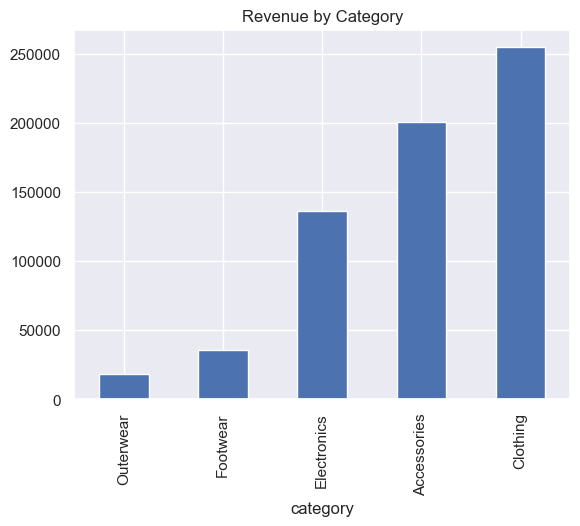

In [28]:
category_sales = df.groupby('category')['purchase_amount'].sum().sort_values()

category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

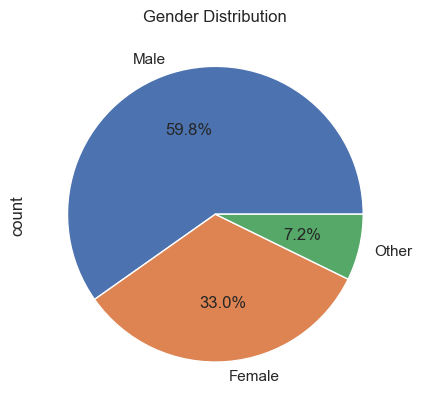

In [30]:
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

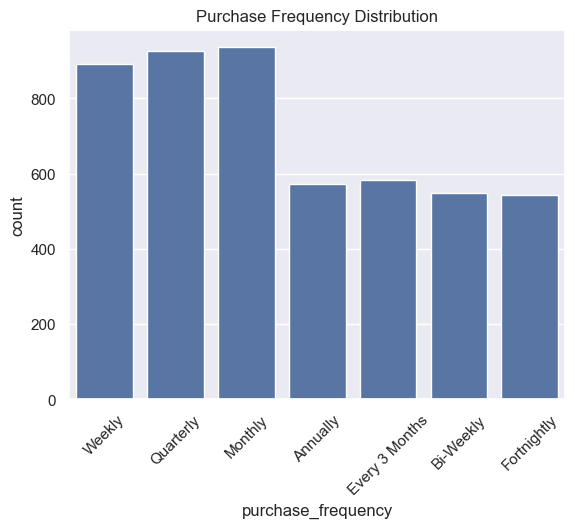

In [32]:
sns.countplot(x='purchase_frequency', data=df)
plt.title("Purchase Frequency Distribution")
plt.xticks(rotation=45)
plt.show()

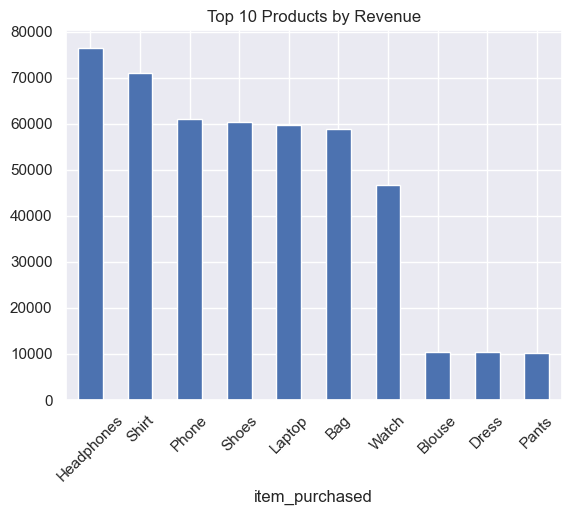

In [46]:
top_items = df.groupby("item_purchased")["purchase_amount"].sum().sort_values(ascending=False).head(10)

top_items.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xticks(rotation=45)
plt.show()

In [47]:
rfm = df.groupby('customer_id').agg({
    'purchase_amount': 'sum',
    'previous_purchases': 'mean'
})

rfm.columns = ['Monetary', 'Frequency']

In [49]:
rfm

,Monetary,Frequency
customer_id,,
1,53.00,14.0
2,64.00,2.0
3,73.00,23.0
4,90.00,49.0
5,49.00,31.0
...,...,...
5095,0.00,24.0
5096,0.00,NaN
5097,150.47,10.0


In [52]:
rfm['Segment'] = pd.qcut(rfm['Monetary'], 4, labels=['Low','Mid','High','Top'])

rfm.head()

,Monetary,Frequency,Segment
customer_id,,,
1,53.0,14.0,Mid
2,64.0,2.0,High
3,73.0,23.0,High
4,90.0,49.0,Top
5,49.0,31.0,Mid


C:\Users\manid\AppData\Local\Temp\ipykernel_6860\2778264061.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = rfm.groupby('Segment')['Monetary'].sum()


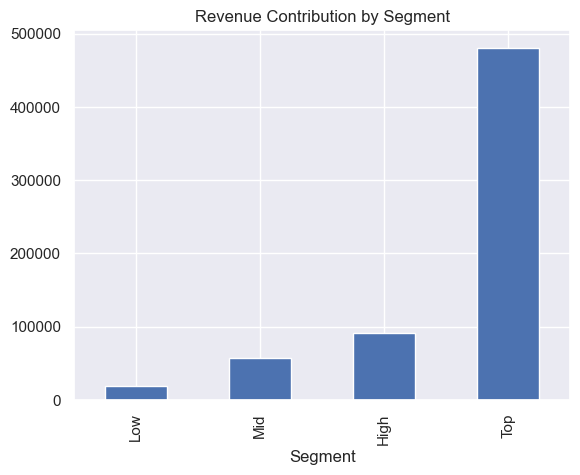

In [54]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()

segment_revenue.plot(kind='bar')
plt.title("Revenue Contribution by Segment")
plt.show()

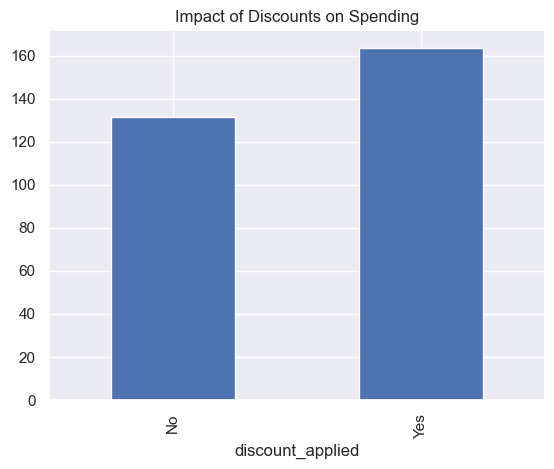

In [57]:
df.groupby('discount_applied')['purchase_amount'].mean().plot(kind='bar')
plt.title("Impact of Discounts on Spending")
plt.show()

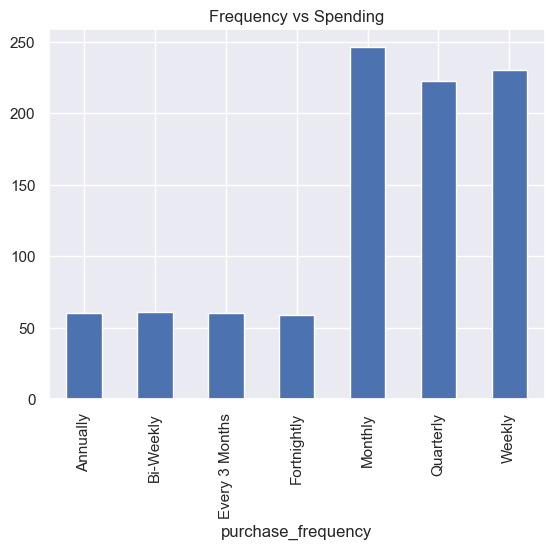

In [59]:
df.groupby('purchase_frequency')['purchase_amount'].mean().plot(kind='bar')
plt.title("Frequency vs Spending")
plt.show()

key insights from analysis
1.Clothing is the highest revenue-generating category
2.High-value customers contribute most of the revenue
3.Frequent buyers spend significantly more
4.Discounts increase purchase value
5.Subscription users tend to spend more